In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all the forecast datas
xgb_df = pd.read_csv('../results/xgboost_forecast_results.csv')
arima_df = pd.read_csv('../results/arima_forecast_results.csv')
var_df = pd.read_csv('../results/var_forecast_results.csv')
lstm_df = pd.read_csv('../results/lstm_forecast_results.csv')


In [21]:
arima_df['Date'] = pd.to_datetime(arima_df['Date'], format='%m/%d/%Y').dt.strftime('%Y-%d-%m')
var_df['Date'] = pd.to_datetime(var_df['Date'], format='%m/%d/%Y').dt.strftime('%Y-%d-%m')
lstm_df['Date'] = pd.to_datetime(lstm_df['Date'], format='%m/%d/%Y').dt.strftime('%Y-%d-%m')

In [22]:
merged = arima_df[['Date', 'Actual_GDP']].copy()

# Merge forecasts
merged = merged.merge(arima_df[['Date', 'ARIMA_Forecast']], on='Date', how='outer')
merged = merged.merge(var_df[['Date', 'VAR_Forecast']], on='Date', how='outer')
merged = merged.merge(xgb_df[['Date', 'XGBoost_Forecast']], on='Date', how='outer')
merged = merged.merge(lstm_df[['Date', 'LSTM_Forecast']], on='Date', how='outer')

# Sort by date
merged = merged.sort_values('Date').reset_index(drop=True)




In [23]:
merged = merged.dropna(subset=['Actual_GDP'])

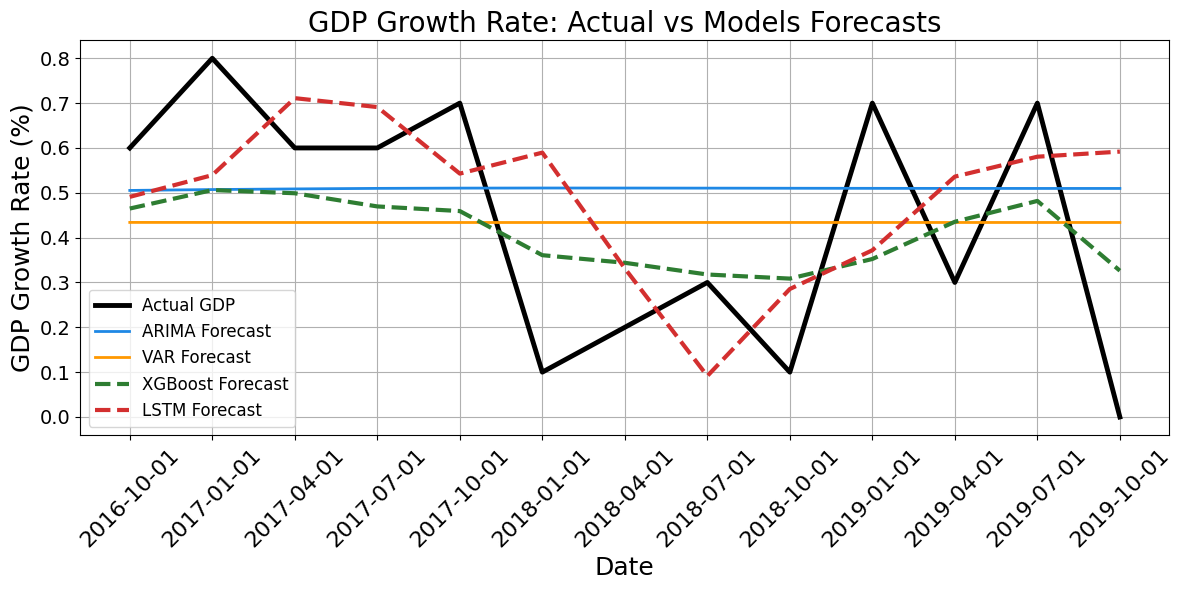

In [24]:
import matplotlib.dates as mdates
import numpy as np

plt.figure(figsize=(12, 6))


colors = {
    'actual': '#000000',
    'arima': '#1e88e5',
    'var': '#ff9800',
    'xgboost': '#2e7d32',
    'lstm': '#d32f2f'
}


styles = {
    'actual': '-',
    'arima': '-',
    'var': '-',
    'xgboost': '--',
    'lstm': '--'
}


widths = {
    'actual': 3.5,
    'arima': 2,
    'var': 2,
    'xgboost': 3,
    'lstm': 3
}


plt.plot(merged['Date'], merged['Actual_GDP'], label='Actual GDP',
         color=colors['actual'], linestyle=styles['actual'], linewidth=widths['actual'])

if 'ARIMA_Forecast' in merged.columns:
    plt.plot(merged['Date'], merged['ARIMA_Forecast'], label='ARIMA Forecast',
             color=colors['arima'], linestyle=styles['arima'], linewidth=widths['arima'])

if 'VAR_Forecast' in merged.columns:
    plt.plot(merged['Date'], merged['VAR_Forecast'], label='VAR Forecast',
             color=colors['var'], linestyle=styles['var'], linewidth=widths['var'])

if 'XGBoost_Forecast' in merged.columns:
    plt.plot(merged['Date'], merged['XGBoost_Forecast'], label='XGBoost Forecast',
             color=colors['xgboost'], linestyle=styles['xgboost'], linewidth=widths['xgboost'])

if 'LSTM_Forecast' in merged.columns:
    plt.plot(merged['Date'], merged['LSTM_Forecast'], label='LSTM Forecast',
             color=colors['lstm'], linestyle=styles['lstm'], linewidth=widths['lstm'])


plt.title('GDP Growth Rate: Actual vs Models Forecasts', fontsize=20)
plt.xlabel('Date', fontsize=18)
plt.ylabel('GDP Growth Rate (%)', fontsize=18)


plt.grid(True)

plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=14)

plt.legend(fontsize='large')
plt.tight_layout()

plt.show()